In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/ipl.csv.txt")
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [ ]:
df.isnull().sum()

,0
mid,0
date,0
venue,0
bat_team,0
bowl_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [ ]:
df = df.drop(columns=[
    'mid',
    'date',
    'batsman',
    'bowler',
    'striker',
    'non-striker'
])

In [ ]:
df.head()

,venue,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,1,0,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,1,0,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,2,0,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,2,0,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,2,0,222


In [ ]:
df = df[df['overs'] >= 5.0]

In [ ]:
df.shape

(56707, 9)

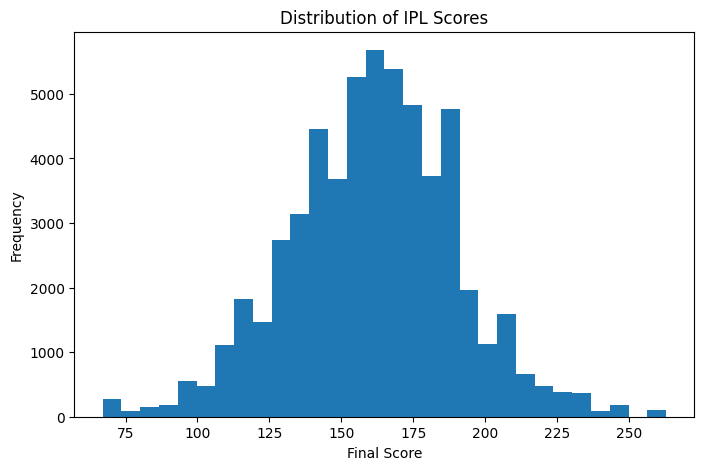

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['total'], bins=30)
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.title("Distribution of IPL Scores")
plt.show()

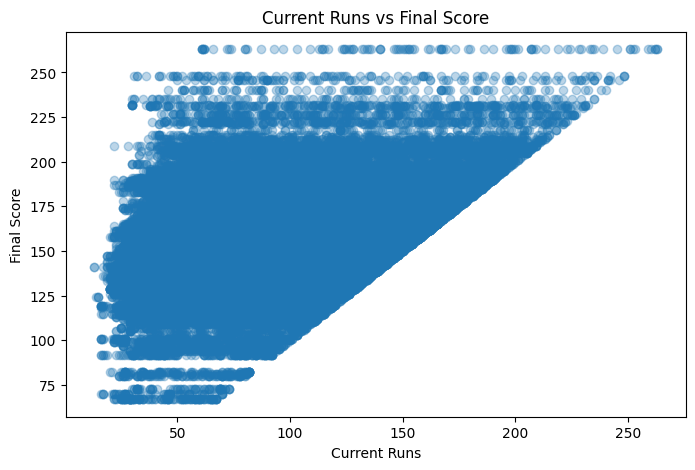

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['runs'], df['total'], alpha=0.3)
plt.xlabel("Current Runs")
plt.ylabel("Final Score")
plt.title("Current Runs vs Final Score")
plt.show()

In [ ]:
venue_encoder = LabelEncoder()
bat_encoder = LabelEncoder()
bowl_encoder = LabelEncoder()

df['venue'] = venue_encoder.fit_transform(df['venue'])
df['bat_team'] = bat_encoder.fit_transform(df['bat_team'])
df['bowl_team'] = bowl_encoder.fit_transform(df['bowl_team'])

In [ ]:
df.head()

,venue,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,14,6,12,61,0,5.1,59,0,222
33,14,6,12,61,1,5.2,59,1,222
34,14,6,12,61,1,5.3,59,1,222
35,14,6,12,61,1,5.4,59,1,222
36,14,6,12,61,1,5.5,58,1,222


In [ ]:
X = df.drop('total', axis=1)

In [ ]:
y = df['total']

In [ ]:
print(X.shape)
print(y.shape)

(56707, 8)
(56707,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(45365, 8)
(11342, 8)


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
train_score = model.score(X_train, y_train)
print("Train R2 Score:", train_score)

Train R2 Score: 0.9937141759503815


In [ ]:
test_score = model.score(X_test, y_test)
print("Test R2 Score:", test_score)

Test R2 Score: 0.9538470350851433


In [ ]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Train Score:", train_score)
print("Test Score:", test_score)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Train Score: 0.9937141759503815
Test Score: 0.9538470350851433
MAE: 3.6567728050398434
RMSE: 6.289772285207119
R2 Score: 0.9538470350851433


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': pred[:10]
})

comparison

,Actual,Predicted
0,178,173.555
1,139,140.045
2,112,111.970
3,114,114.475
4,152,146.900
5,125,125.325
6,148,145.680
7,149,149.380
8,178,177.605
9,158,142.045


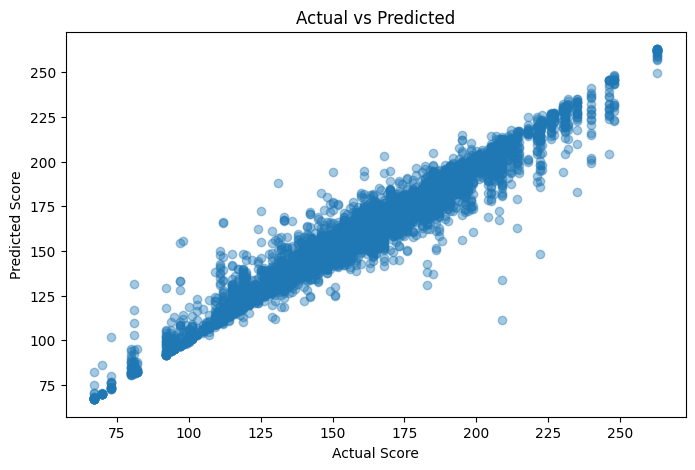

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, pred, alpha=0.4)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
importance = model.feature_importances_
features = X.columns

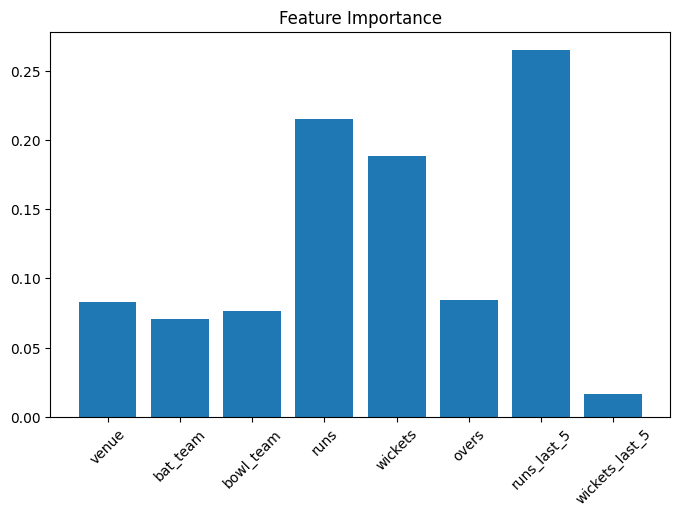

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
sample = pd.DataFrame({
    'venue':[3],
    'bat_team':[1],
    'bowl_team':[5],
    'runs':[120],
    'wickets':[3],
    'overs':[15.2],
    'runs_last_5':[42],
    'wickets_last_5':[1]
})

In [ ]:
prediction = model.predict(sample)
print("Predicted Score:", prediction[0])

Predicted Score: 169.44
